# \[set-up\], imports
Reminder (if working on the notebook server): make sure your copy of `pint_pal` is up to date and you're working on a development branch, e.g. `psr/J1234+5678/jks`. 

#### To install the environment on Link:
1. Use Ross and Scott's `pixi.toml` file (now in NG20 repo) and upload it in the base dir of where you'd like to install it
2. From the command line run:
   ```
   curl -fsSL https://pixi.sh/install.sh | bash
   pixi global install gcc # If installing locally, this won't be needed
   pixi install
   pixi run install-kernel
   ```
3. A new kernel called `ng20-next` should have appeared. Run the nb with in that kernel.

In [1]:
import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
import pint.models as pm
import pint_pal.par_checker as pc
import pint_pal.dmx_utils as du
import pint_pal.discovery_utils as disco_utils
import pint_pal.lite_utils as lu
import pint_pal.noise_utils as nu
import pint_pal.plot_utils as pu
from pint_pal.ftester import run_Ftests
from pint_pal.utils import resid_stats, pdf_writer, apply_cut_select
from pint_pal.utils import check_recentness_excision, check_recentness_noise
from pint_pal.timingconfiguration import TimingConfiguration
from astropy import log
from pint.fitter import ConvergenceFailure
import pint.fitter
from pint.utils import dmxparse
import pprint
import os
import copy
from astropy.visualization import quantity_support
quantity_support()

# notebook gives interactive plots but not until the kernel is done
# %matplotlib notebook
# inline gives non-interactive plots right away
%matplotlib inline

In [3]:
import numpy as np
import astropy.units as u
import pint

from pint_pal.BBX import (
    RunConfig, InputConfig, OutputPaths, OutputConfig,
    SolarWindProxy, BBX, DispersionMeasureProxy,
    ProxyConfig, BBXConfig, SolarWindConfig,
    PicklerIO, CachePolicy, PicklerBundle,
)

import matplotlib.pyplot as plt
from pint_pal.BBX import diagnostics as dia
from pint_pal.BBX import utils as ut

In [4]:
# default assumption is that notebook is being run by hand
run_Ftest = True  # Set to False if you don't need F-tests and want a faster notebook run!

In [5]:
log.setLevel("INFO") # Set desired verbosity of log statements (DEBUG/INFO/WARNING/ERROR)
log_to_file = False

if pint.__version__ > '0.8.6':  # see https://github.com/nanograv/PINT/blob/master/CHANGELOG.md
    pint.logging.setup(level="WARNING", usecolors=True)

lu.git_config_info()

WARNING  (pint_pal.par_checker          ): Wrong bipm_version (BIPM2023); should be BIPM2021.
ERROR    (pint_pal.par_checker          ): TOAs from multiple releases should not be combined: {None, 'TEMP'}


# Load par and config from v1.1

Load configuration (`.yaml`) file, get TOAs and timing model; if you're running from the root of the git distribution, simply edit the `.yaml` file name, otherwise include relevant paths to the `.yaml` file, and `.par`/`.tim` directories as kwargs (see commented example).

In [6]:
config = "/Users/msthomps/Documents/Research/timsNpars/ChromaticCageMatch/configs/B1953+29.nb.yaml"  # fill in actual path

par_directory = '/Users/msthomps/Documents/Research/timsNpars/ChromaticCageMatch/results/'   # default location
tim_directory = '/Users/msthomps/Documents/Research/timsNpars/ChromaticCageMatch/toas/'      # default location
tc = TimingConfiguration(config, par_directory=par_directory, tim_directory=tim_directory)

using_wideband = tc.get_toa_type() == 'WB'

# Inputs needed for BB segmentations - pulsarName, tim, and par files
pulsarName = tc.get_source()
par_file = tc.get_model_path()

# Use excise.tim file if it exists, else revert to raw TOAs & initial cuts
#mo, to = pint.models.get_model_and_toas(par_file, tim_file)
mo, to = tc.get_model_and_toas(excised=True, usepickle=False)
if not to: mo,to = tc.get_model_and_toas(apply_initial_cuts=True)
#tc.manual_cuts(to) # IndexError: arrays used as indices must be of integer (or boolean) type

# Make temp tim or point to current/excised tim
if tc.config["intermediate-results"]['excised-tim']:
    # Load tim directly - assumes most recent tim is the correct tim
    tim_file = ut.find_recent_file(tim_directory, pulsarName, "*.tim") 
else:
    tmp_tim_dir = os.getcwd() + "/timtemp"
    os.makedirs(tmp_tim_dir, exist_ok=True)
    tim_file = os.path.join(tmp_tim_dir, f"{pulsarName}_temp.tim")
    to.write_TOA_file(tim_file)

if log_to_file:
    lu.log_notebook_to_file(tc.get_source(), tc.get_toa_type())
    lu.log_warnings()

Most recent file found: /Users/msthomps/Documents/Research/timsNpars/ChromaticCageMatch/toas/B1953+29_PINT_20250516.nb.tim


In [7]:
# Computing pulse numbers ensures param changes in the model will not break phase connection
to.compute_pulse_numbers(mo)
to

7889 TOAs starting at MJD 54998.2842435241

# Sanitize the model

Remove DMX and Add DM1, DM2. Unfreeze DM, DM1, DM2. Add (deterministic) mean solar wind NE_SW.

In [8]:
# Sanitize the model
try:
    mo.components['DispersionDMX']
except:
    print('DMX already removed')

lu.remove_noise(mo, noise_components=['DispersionDMX', 'SolarWindDispersionX'])

# Add basic components
lu.add_DM1_DM2_and_unfreeze_DM(mo, DM2=True,frozen=False)
lu.add_deteriministic_solar_wind_to_model(mo, NE_SW=6.67, frozen=False, SWM=1)

# Sanity check
#list(mo.components.keys())
mo.components['DispersionDM'], mo.components['SolarWindDispersion']

(DispersionDM(
     floatParameter( DM                  104.50416742110741 (pc / cm3) frozen=False),
     floatParameter( DM1                 0.0               (pc / (yr cm3)) frozen=False),
     MJDParameter(   DMEPOCH             57860.0000000000000000 (d) frozen=True),
     floatParameter( DM2                 0.0               (pc / (yr2 cm3)) frozen=False)),
 SolarWindDispersion(
     floatParameter( NE_SW               6.67              (1 / cm3) frozen=False),
     floatParameter( NE_SW1              0.0               (1 / (yr cm3)) frozen=True),
     MJDParameter(   SWEPOCH             57860.0000000000000000 (d) frozen=True),
     floatParameter( SWP                 2.0               () frozen=True),
     intParameter(   SWM                 1                 frozen=True)))

In [9]:
lu.center_epochs(mo,to)
to.print_summary()

Number of TOAs:  7889
Paradigm: narrowband
Number of commands:  1
Number of observatories: 2 ['arecibo', 'chime']
MJD span:  54998.284 to 60721.758
Date span: 2009-06-16 06:49:18.640481705 to 2025-02-15 18:10:54.684210151
arecibo TOAs (5200):
  Min freq:      422.186 MHz
  Max freq:      2378.000 MHz
  Min error:     1.11 us
  Max error:     42.6 us
  Median error:  3.49 us
chime TOAs (2689):
  Min freq:      424.396 MHz
  Max freq:      675.985 MHz
  Min error:     3.62 us
  Max error:     43.5 us
  Median error:  17.9 us



**Run basic checks:** for pulsar name, solar system ephemeris, clock correction, ecliptic coordinates, tropospheric delays, planet Shapiro delays, and if applicable, removal of Arecibo data affected by bad LO. Check that TOAs being used are from the latest `toagen` release. Also check for the appropriate number of receiver JUMPs and DMJUMPs and fix them automatically if necessary.

In [10]:
pc.check_settings(mo,to)

receivers = lu.get_receivers(to)
lu.add_feJumps(mo,receivers)
if using_wideband:
    lu.add_feDMJumps(mo,receivers)
#pc.check_jumps(mo,receivers,toa_type=tc.get_toa_type())

#if not autorun: check_recentness_excision(tc)

# Create Bayesian Blocking (BB) segmentations + DM proxy's (SW + IISM)
---

<details>
<summary><strong>The Basics of the "BBX" Method</strong></summary>

The Bayesian Blocks (BB) segmentation procedure follows the same basic steps regardless of signal source:

1. Choose and build a DM proxy.
   - For the SW this is the sun-Earth-pulsar integral.
   - For DM you can build the DM proxy using 3 methods:
     - using epochwise WLS fits,
     - Extracting the DM time series from dmxparse of a finely binned DMX fit, or
     - use the 1/$\nu^2$ weighted residuals directly.
3. Run the BB algorithm on the proxy to get an initial segmentation. This is often statistically optimal under the chosen fitness function, but may be practically unrealistic (e.g. bin intervals are large/tiny, bins that straddle data gaps, etc...).
4. Enforce "bin logic" constraints, such as minimum number of toa counts in each bin and minimum/maximum bin interval lengths
5. Identify and remove data gaps. Large gaps bias the BB fitness evaluation causing binning to deviate from the structure we're hoping to capture. To mitigate this effect, intervals corresponding to data gaps are excluded from the segmentation. This removal can create bins that violate our constraints.
7. Reapply the constraints to the gap-excluded segmentation to merge/adjust any bins that now violate the bin-logic rules. **This yields the final BB segmentation.**

The code is organized into configuration objects, which store inputs, and runner objects, which perform the computation. Lets set it up, first for the solar wind, then DM!

---
</details>

In [11]:
# Create configuration objects - basic setup
cfg = RunConfig(
    inp=InputConfig( # Only required user inputs
        pulsar_name=pulsarName, 
        par_file=par_file, 
        tim_file=tim_file
        )
)

paths = OutputPaths.from_config(cfg)
out_cfg = OutputConfig(diagnostics="on", save_figures=True, root_fig_dir=paths.fig_dir)
paths.ensure_fig_dir(enabled=out_cfg.save_figures)

bbx = BBX(pickler=None, dm_proxy=DispersionMeasureProxy(pickler=None))
sw_proxy = SolarWindProxy(bbx=bbx)

In [12]:
# Create SW BB segmentation
sw_cfg = SolarWindConfig(
    model="SWX",
    ne1au=7.9,
    ephem="DE440",
    min_theta_deg=0.25,
    include_Re=True,
)

bbx_cfg_sw = BBXConfig(
    fitness="measures",
    p0=0.14,
    min_toas=8,
    min_time=0.1 * u.d,
    max_time=365.25 * u.d,
    gap_threshold_days=200.0,
    trim_days=1.0,
    signal_source="swx",
)

proxy_result_sw, pipe_sw = sw_proxy.build_swx_bb_edges_from_proxy(
    toas=to,
    model=mo,
    sw_cfg=sw_cfg,
    bbx_cfg=bbx_cfg_sw,
    pulsar_name=pulsarName,
)

In [14]:
sw_edges = np.asarray(pipe_sw["SW_BB_refined"], float)
print("SWX BB refined edges span:", [int(sw_edges[0]), int(sw_edges[-1])])
print("N bins:", (len(sw_edges) - 1))

SWX BB refined edges span: [54998, 60721]
N bins: 17


<details>
<summary><strong>Evaluating the Solar Wind Segmentation and Proxy creation</strong></summary>

This diagnostic figure summarizes: the SW DM proxy time series used for Bayesian Block segmentation, the resulting segmentation, and gap identification. It should be used to evaluate if the SW DM proxy result (Sun–Earth–pulsar integral) is sensible and the BB segmentation traces the structure it displays. It is important to note, that at this point in the notebook, no SW or DM contributions have been fit or removed.


**Top left: SW proxy time series + BB segmentation**

What this panel shows: the SW DM proxy vs time (orange points), the BB segmentation (alternating shaded spans), and the observation gaps identified (red shaded region(s))

What you want to see:
- Clear structure in the proxy near solar conjunction seasons (expected yearly behavior).
- BB segments track real structure (changes in slope/level).
- No build up of many small/large bins unless justified by the proxy structure.

If it looks wrong, adjust:
- `p0`
  - Too many bins (over-segmentation): decrease `p0`.
  - Too few bins (under-segmentation): increase `p0`.
- `mindata` / `mintime` / `maxtime`
  - If bins are too small / unstable: increase `mindata` and/or `mintime`.
  - If bins are too large and miss structure: decrease `maxtime` (and/or raise `p0` if you want fewer bins but still allow smaller bins where needed).
- `min_theta_deg`
  - If proxy is dominated by points at very small elongation: increase `min_theta_deg`.
  - If bins are not capturing additional structure near conjunction and losing the peak: decrease `min_theta_deg` cautiously.
- `gap_threshold_days`
  - If true gaps (regions with no data) are missed: increase/decrease `gap_threshold_days` accordingly.
  - Flagging routine cadence as “gaps”: increase `gap_threshold_days`.
- `trim_days`
  - If data is being removed around gaps: decrease `trim_days`.


**Top right: Histogram of Bin Spacings**

What this panel typically indicates: typical lengths of bin intervals/spacings

What you want to see:
- Conjunction seasons (annual minima in elongation) align with where the proxy shows the strongest excursions.
- No obvious phase shift of conjunction (could suggest ephemeris mismatch or coordinate issues).

If it looks wrong, adjust:
- `ephem`
  - Use the same ephemeris your data is processed in (e.g DE440 as shown).
- `include_Re`
  - If you want (or do not want) the Earth-radius term in the integral, toggle `include_Re` and confirm the expected amplitude/shape change.
- `min_theta_deg`
  - If the panel shows you are including points too close to the Sun (numerically singular), increase `min_theta_deg`.


**Bottom row: Peak Zoom-in's**

What this panel typically shows: n peak zoom-ins evenly selected across the MJD span. Intended to be used to examine the segmentation structure at peaks, where greater variation is expected.

What you want to see:
- Gradation reflects proxy structure (e.g. large bins don't contain multiple distinct regions of differing structure).
- Segmentation constraints are enforced (e.g. `mindata` / `mintime` / `maxtime`; rough estimate)

If it looks wrong, adjust:
- `p0`
  - Too many bins (over-segmentation): decrease `p0`.
  - Too few bins (under-segmentation): increase `p0`.
- `mindata` / `mintime` / `maxtime`


**Practical workflow**
1) First ensure the DM proxy (top left; orange pts) look physically consistent (conjunction seasons yearly cadence).
2) Tune gap handling (`gap_threshold_days`, `trim_days`) so gaps correspond to real observing gaps and no data is cut from the proxy.
3) Tune segmentation parameters (`p0`, `mindata`, `mintime`, `maxtime`) so bins track proxy structure without overfitting.
4) Check that bins do not straddle gaps and that bins remain within constraints.

*General rule of thumb:* Pulsars closer to the ecliptic should contain greater SW contributions and therefor produce more variance in the final segmentations (e.g. more variation in spacings, regions of smaller bins around peaks, and larger bins between peaks and valleys). In pulsars further away from the ecliptic with lower SW contributions, typically, segmentations have less variation and produce relatively even yearly bins. Many principles of the segmentation evaluation here also apply to the DM BB segmentation below.

---
</details>

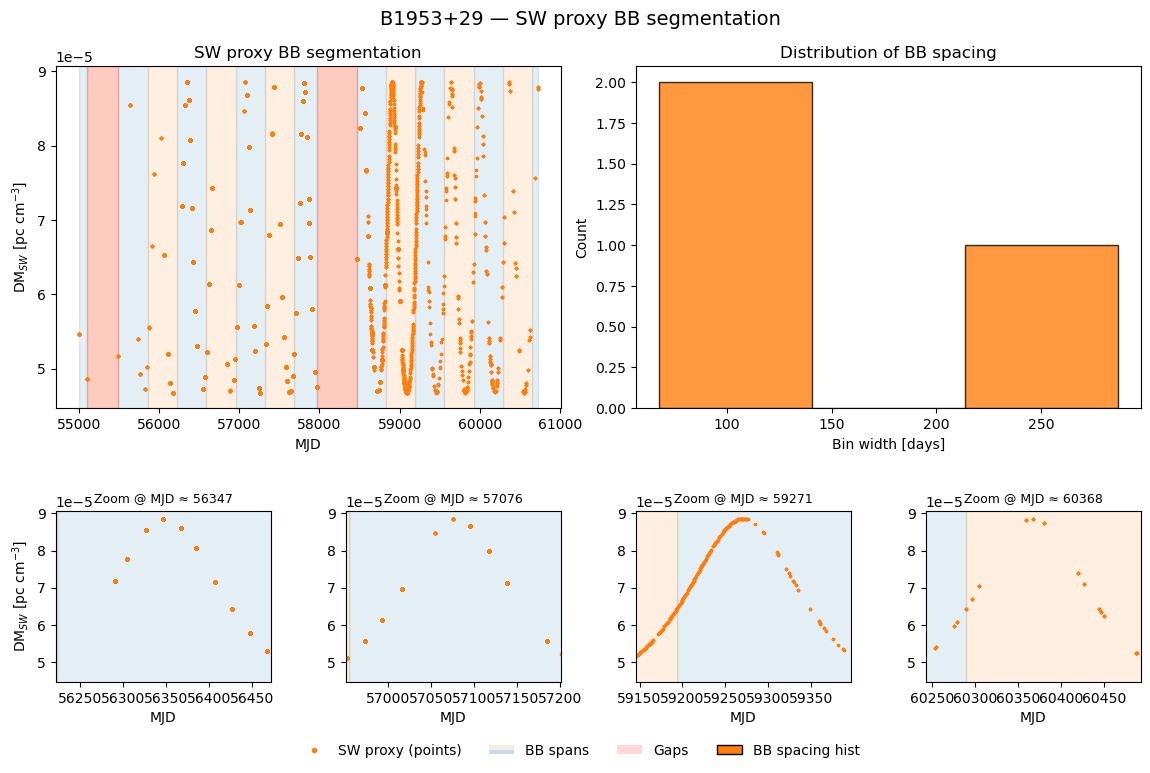

In [16]:
# The segmentation diagnostic plot
fig_sw = dia.plot_swx_bb_diagnostics(pipe_sw, style=cfg.out.plot)  # or style=None
plt.show()

##### We use the midpoint of each Bayesian Blocks bin as a node in time, and construct basis functions on these nodes to represent the solar-wind Gaussian process in the time domain. We will do the same for Dispersion Measure below.

In [17]:
# Create node MJD from SW BB segmentations
r1 = sw_edges[:-1]              # left edges
r2 = sw_edges[1:]               # right edges
sw_basis_nodes0 = 0.5 * (r1 + r2) # midpoints

# Remove gap nodes
gap_nodes = np.array([(0.5 * (r1 + r2)) for r1, r2 in pipe_sw["sw_gaps"]])
sw_basis_nodes, _ = ut.remove_gap_nodes(
    sw_basis_nodes0,
    gap_nodes,
    atol=1e-10,
)

print("N bins:", (len(sw_edges) - 1))
print("N gaps:", len(gap_nodes))
print("N nodes:", len(sw_basis_nodes))

N bins: 17
N gaps: 2
N nodes: 15


### Make IISM DM Segmentation

In [18]:
# Choose DM proxy and BB settings to set up configs
proxy_cfg = ProxyConfig(
    signal_source="chromatic",  # "chromatic" | "residuals" | "dmx"
    epoch_tol_days=2.5,
    use_inv_nu2=True,
    min_channels=6,             # min_channels cannot be < min_unique_channels
    min_unique_channels=2,
    min_x_span=1.0e-7,
    return_dm_units=True,
)

bbx_cfg = BBXConfig(
    fitness="measures",
    p0=0.14,
    min_toas=8,
    min_time=0.8 * u.d,
    max_time=80.0 * u.d,
    gap_threshold_days=200.0,
    trim_days=1.0,
    signal_source="chromatic",  
)

pipe_dm = bbx.build_dm_bb_edges_from_proxy(
    model=mo,
    toas=to,
    proxy_cfg=proxy_cfg,
    bbx_cfg=bbx_cfg,
    pulsar_name=pulsarName,
    fitter_cls=pint.fitter.WLSFitter,
    allow_temp_fitter=True,       # lets BBX compute residuals/errs if not provided (chromatic/residuals)
    return_gap_diagnostics=True, 
)

In [19]:
dm_edges = np.asarray(pipe_dm["tBB_final"], float)
print("BBX edges span:", [int(dm_edges[0]), int(dm_edges[-1])])
print("N bins:", len(dm_edges) - 1)

BBX edges span: [54998, 60720]
N bins: 79


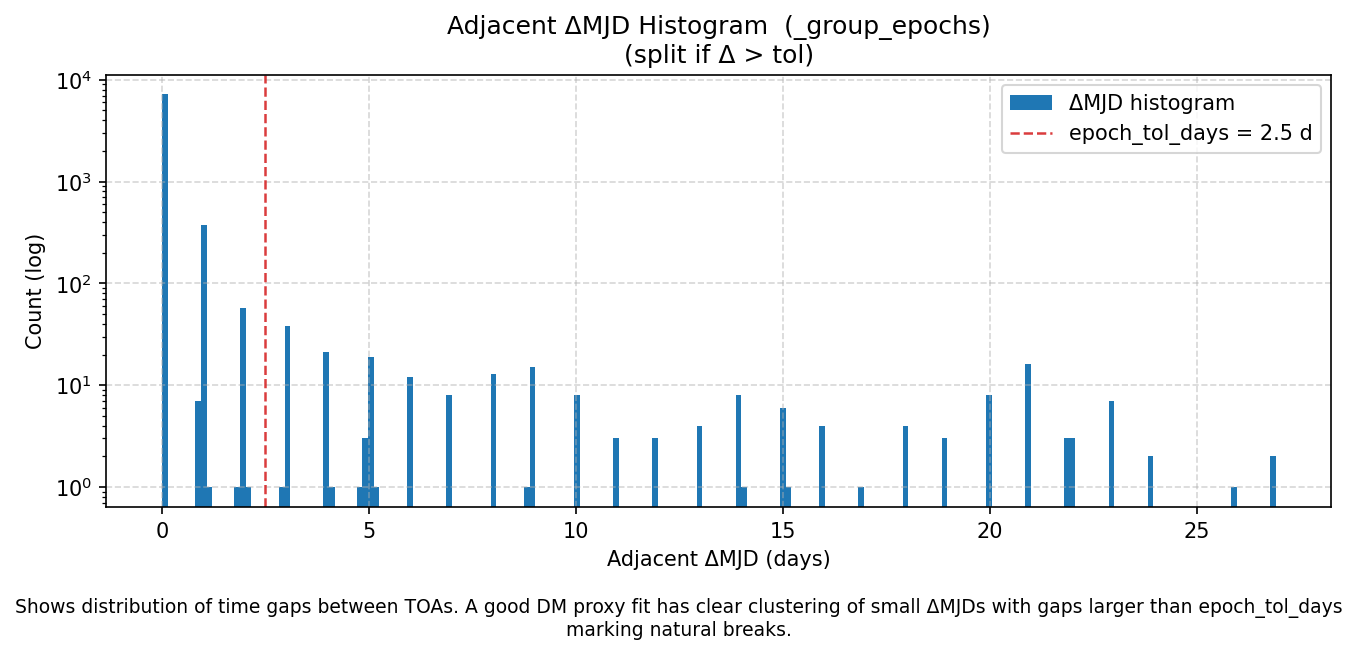

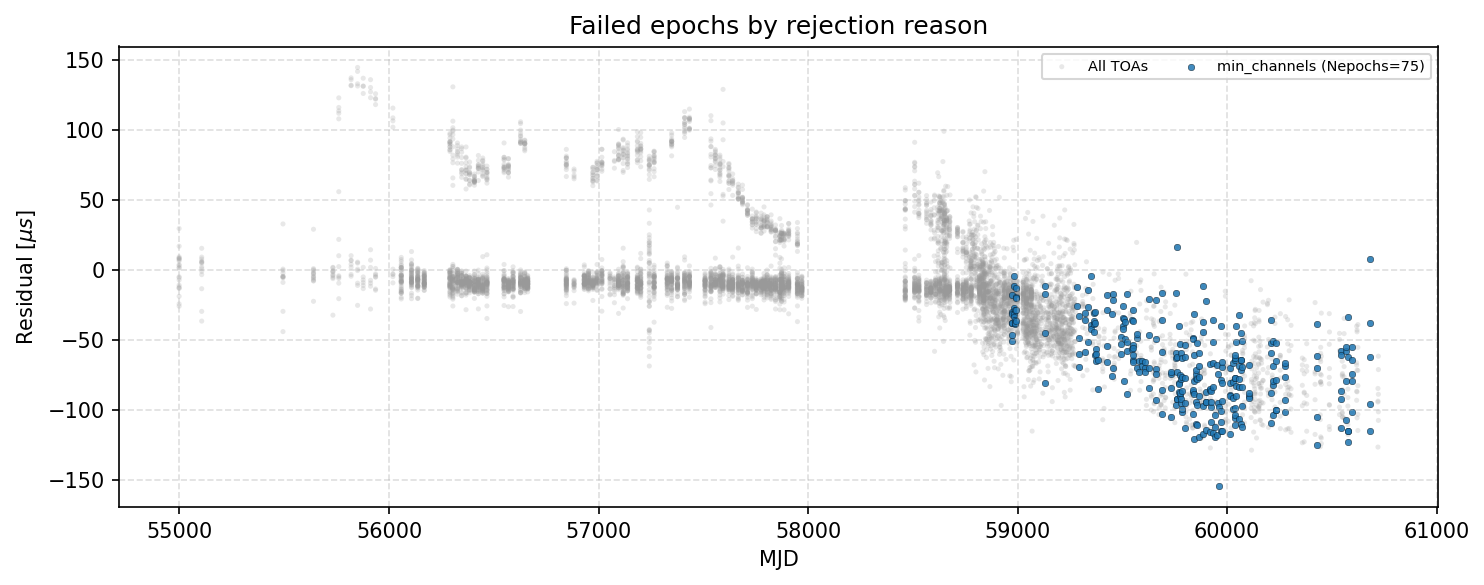

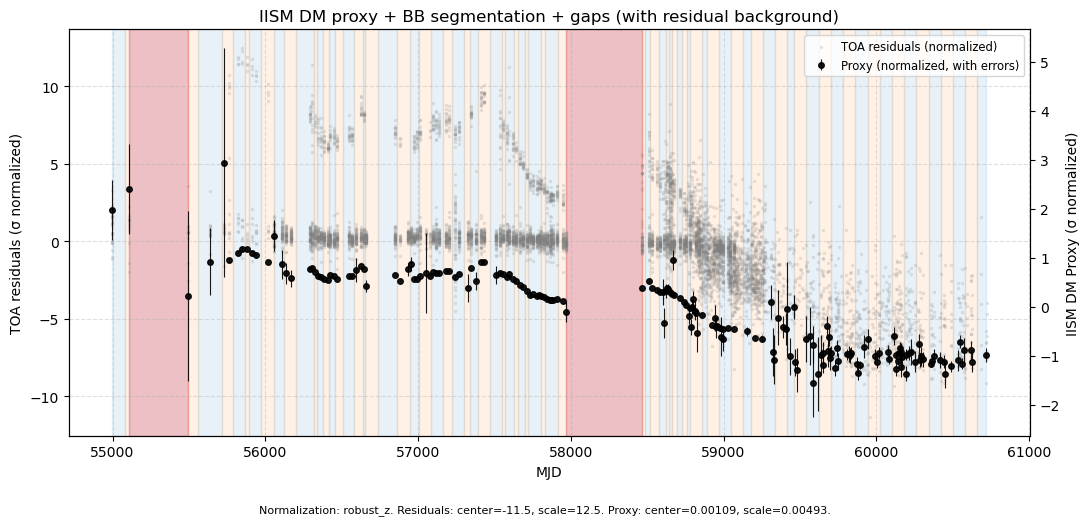

In [20]:
dm_diag = bbx.run_dm_segmentation_diagnostics(
    pipe=pipe_dm,
    out=out_cfg,
    paths=paths,
    style=out_cfg.plot,
    stem_prefix=f"{pulsarName}_bbx_dmproxy",
    plot_verbose=False,
)

In [21]:
# Create node MJD from DM BB segmentations
r1 = dm_edges[:-1]              # left edges
r2 = dm_edges[1:]               # right edges
dm_basis_nodes0 = 0.5 * (r1 + r2) # midpoints

# Remove gap nodes
gap_nodes = np.array([(0.5 * (r1 + r2)) for r1, r2 in pipe_dm["gaps"]])
dm_basis_nodes, _ = ut.remove_gap_nodes(
    dm_basis_nodes0,
    gap_nodes,
    atol=1e-10,
)

print("N bins:", len(dm_edges) - 1)
print("N gaps:", len(gap_nodes))
print("N nodes:", len(dm_basis_nodes))

N bins: 79
N gaps: 2
N nodes: 77


### Construct a fitter & Plot prefit residuals.

This should look scary bad since we no longer have a DM model.

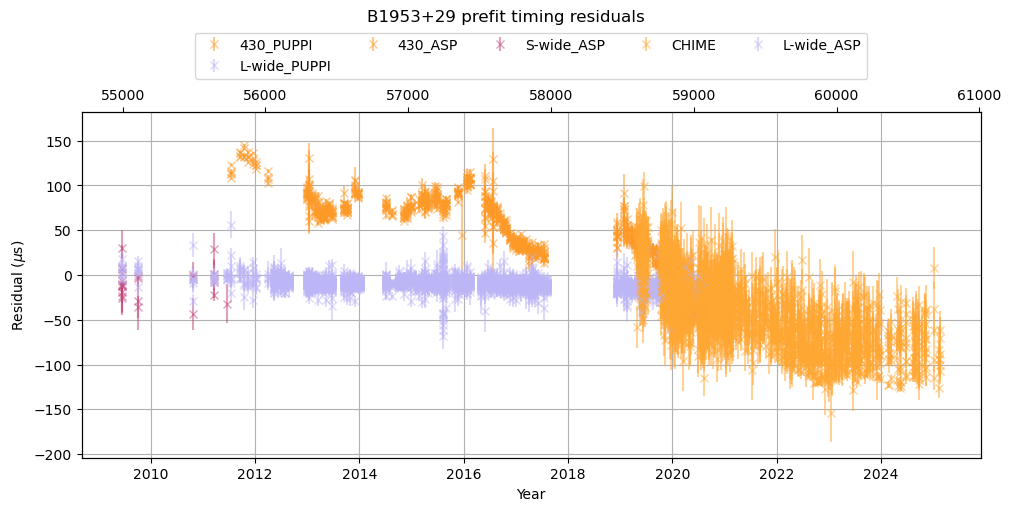

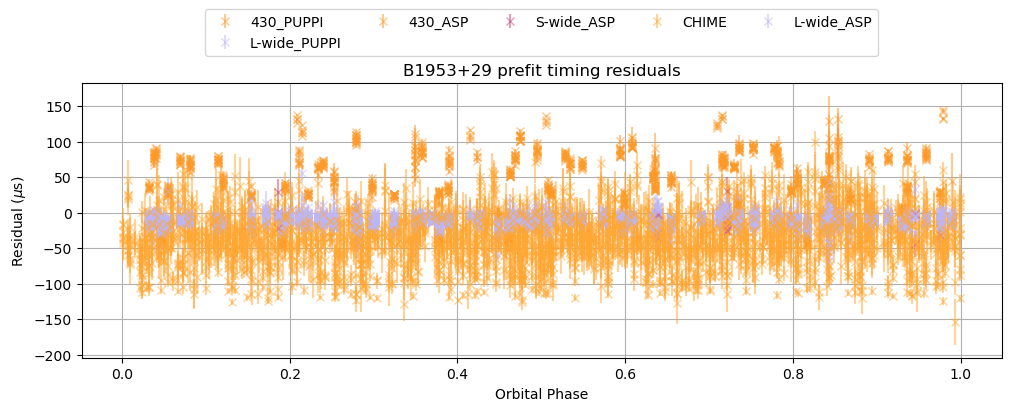

In [22]:
# Define the fitter object and plot pre-fit residuals
fo = tc.construct_fitter(to,mo)

pu.plot_residuals_time(fo, restype='prefit')

if mo.is_binary:
    pu.plot_residuals_orb(fo, restype='prefit')
    
if using_wideband:
    pu.plot_dm_residuals(fo, restype='prefit')

## We don't want to fit the timing model here since it has no DM model !

So let's skip a pre-noise timing model refit! Commented out for now...

In [24]:
# Check that free-params follow NANOGrav conventions, fit
fo.model.free_params = tc.get_free_params(fo)
lu.check_fit(fo,skip_check=tc.skip_check)

# try:
#     fo.fit_toas(maxiter=tc.get_niter())
#     fo.model.CHI2.value = fo.resids.chi2
# except ConvergenceFailure:
#     run_Ftest = False
#     log.warning('Failed to converge; moving on with best result, but should address before final version.')

In [25]:
# Plot post-fit residuals, print summary of results, write prenoise solution
# pu.plot_residuals_time(fo, restype='postfit')
# if mo.is_binary:
#     pu.plot_residuals_orb(fo, restype='postfit')
# if using_wideband:
#     pu.plot_dm_residuals(fo, restype='postfit')
    
# if not autorun: fo.print_summary()
# lu.check_convergence(fo)

# lu.write_par(fo,toatype=tc.get_toa_type(),addext='_prenoise',include_date=True)

## Check that your config file has the updated `noise-run` block.

### EXAMPLE CONFIG BLOCK

```yaml
noise_run:

  model:
    timing_model:
      svd: true
      tm_marg: false
    white_noise:
      gp_ecorr: false
      tn_equad: true
      include_ecorr: true
    red_noise:
      basis: fourier
      Nfreqs: 40
      prior: powerlaw
    dm_noise:
      basis: fourier
      Nfreqs: 100
      prior: powerlaw
    solar_wind:
      basis: interpolation
      basis_nodes: null  ### later we will pass in SW edge midpoints array
      prior: square_exponential
      interp_kind: linear
    chromatic_noise: False

  inference:
     likelihood: discovery
     ####   optimizer   ####
     sampler: optimizer
     num_warmup_steps: 500                    
     max_epochs: 1000                           
     peak_learning_rate: 0.01                             
     gradient_clipping_val: null               
     batch_size: 100                            
     patience: 3                               
     difference_threshold: 20.0   #(tune this)  
     max_num_batches: 50                        
     ####      NUTS      ####
     #sampler: NUTS
     num_samples: 1000
     num_samples_per_checkpoint: 100
     num_warmup: 250
     num_chains: 1
     #### misc
     diagnostics: True
```

In [26]:
# ( update config if necessary )
tc = TimingConfiguration(config, par_directory=par_directory, tim_directory=tim_directory)
pprint.pprint(tc.config['noise_run'])

{'inference': {'difference_threshold': 20,
               'likelihood': 'discovery',
               'n_iter': 1000,
               'num_chains': 1,
               'num_checkpoints': 3,
               'num_samples': 33,
               'num_warmup': 5,
               'patience': 3,
               'sampler': 'optimizer'},
 'model': {'chromatic_noise': False,
           'dm_noise': {'Nfreqs': 100, 'basis': 'fourier', 'prior': 'powerlaw'},
           'red_noise': {'Nfreqs': 40, 'basis': 'fourier', 'prior': 'powerlaw'},
           'solar_wind': {'basis': 'interpolation',
                          'basis_nodes': '<pass in SW edge midpoints>',
                          'interp_kind': 'linear',
                          'prior': 'ridge'},
           'timing_model': {'svd': True, 'tm_marg': False},
           'white_noise': {'gp_ecorr': False,
                           'include_ecorr': True,
                           'tn_equad': True}}}


In [27]:
# Passes nodes into config -> passes it to Discovery
tc.config['noise_run']['model']['solar_wind']['basis_nodes'] = sw_basis_nodes

In [28]:
# Sanity check - were nodes added?
pprint.pprint(tc.config['noise_run'])

{'inference': {'difference_threshold': 20,
               'likelihood': 'discovery',
               'n_iter': 1000,
               'num_chains': 1,
               'num_checkpoints': 3,
               'num_samples': 33,
               'num_warmup': 5,
               'patience': 3,
               'sampler': 'optimizer'},
 'model': {'chromatic_noise': False,
           'dm_noise': {'Nfreqs': 100, 'basis': 'fourier', 'prior': 'powerlaw'},
           'red_noise': {'Nfreqs': 40, 'basis': 'fourier', 'prior': 'powerlaw'},
           'solar_wind': {'basis': 'interpolation',
                          'basis_nodes': array([55052.64325727, 55675.56893512, 56040.81893512, 56406.06893512,
       56771.31893512, 57136.56893512, 57501.81893512, 57827.80359526,
       58645.42572059, 59010.67572059, 59375.92572059, 59741.17572059,
       60106.42572059, 60471.67572059, 60688.02914898]),
                          'interp_kind': 'linear',
                          'prior': 'ridge'},
           'timing_mo

# Run noise analysis
#### `optimizer` outputs a dictionary to `base_op_dir` with the MAP params.
####  `NUTS` outputs a `.feather` file in the `base_op_dir`.

### Optimizer Parameter Tuning Cheat Sheet
<details>
<summary><strong>What to look for in the `optimizer` diagnostics plots (click to expand)</strong></summary>
    
- **Cumulative Loss**
  - **Good:** steady downward trend, then flattening.
  - **Bad:** large oscillations/spikes or increasing trend.
  - **Tune:** lower `peak_learning_rate` if unstable; raise it slightly if flat/too slow.

- **Cumulative Grad Norm**
  - **Good:** decreases over time and stabilizes.
  - **Bad:** persistently huge or noisy spikes.
  - **Tune:** lower `peak_learning_rate`; set `gradient_clipping_val` (e.g. `1.0` to `5.0`) if spikes persist.

- **Cumulative Step Norm**
  - **Good:** moderate early values, shrinking later.
  - **Bad:** very large and noisy (overshooting) or near-zero from start (stalled).
  - **Tune:** lower `peak_learning_rate` if too large; increase `peak_learning_rate` if near-zero/stalled.

- **Cumulative Param Norm**
  - **Good:** settles to a stable plateau.
  - **Bad:** monotonic blow-up or erratic jumps.
  - **Tune:** lower `peak_learning_rate`, enable `gradient_clipping_val`, and consider increasing `num_warmup_steps`.

- **Per-batch relative plots (IQR bands)**
  - **Good:** median trends toward 0 with narrowing spread across batches.
  - **Bad:** wide bands that stay wide or drift away from 0.
  - **Tune:** increase `batch_size` (smoother stats), increase `patience`, reduce `peak_learning_rate`.

---

### Hyperparameter tuning advice (practical defaults)

- `peak_learning_rate`
  - Main stability knob.  
  - Start around `0.01`; try `0.003 to 0.03`.  
  - If loss is jumpy: reduce by 2 to 5 x.

- `num_warmup_steps`
  - Controls how gently LR ramps up.  
  - Increase (`500 -> 1000+`) if early batches are unstable.

- `gradient_clipping_val` (untested)
  - Add when grad norm spikes dominate.  
  - Try `1.0`, `2.0`, or `5.0`.

- `batch_size`
  - Steps per diagnostic batch and early-stopping check window.  
  - Increase (`100 -> 300/500`) for smoother, less noisy decisions.

- `difference_threshold`
  - Minimum improvement needed to reset patience.  
  - If stopping too early: lower it (`5 -> 1`).  
  - If never stopping: raise it (`1 -> 5`).

- `patience`
  - Number of non-improving batches allowed.  
  - Increase (`3 -> 5/8`) for noisy objectives.

- `max_num_batches`
  - Hard cap on training windows.  
  - Increase if still improving near end; decrease if clearly plateaued early.

- `max_epochs`
  - LR schedule horizon (cosine decay length).  
  - Keep roughly comparable to total planned steps: `batch_size * max_num_batches` (same order of magnitude).

---

### TLDR;

- **Loss oscillates hard:** decrease `peak_learning_rate`, increase `num_warmup_steps`, add `gradient_clipping_val`.
- **Loss barely moves:** increase `peak_learning_rate` modestly, lower `difference_threshold`, increase `max_num_batches`.
- **Early stop too aggressive:** increase `patience`, lower `difference_threshold`.
- **Diagnostics too noisy to interpret:** increase `batch_size`.

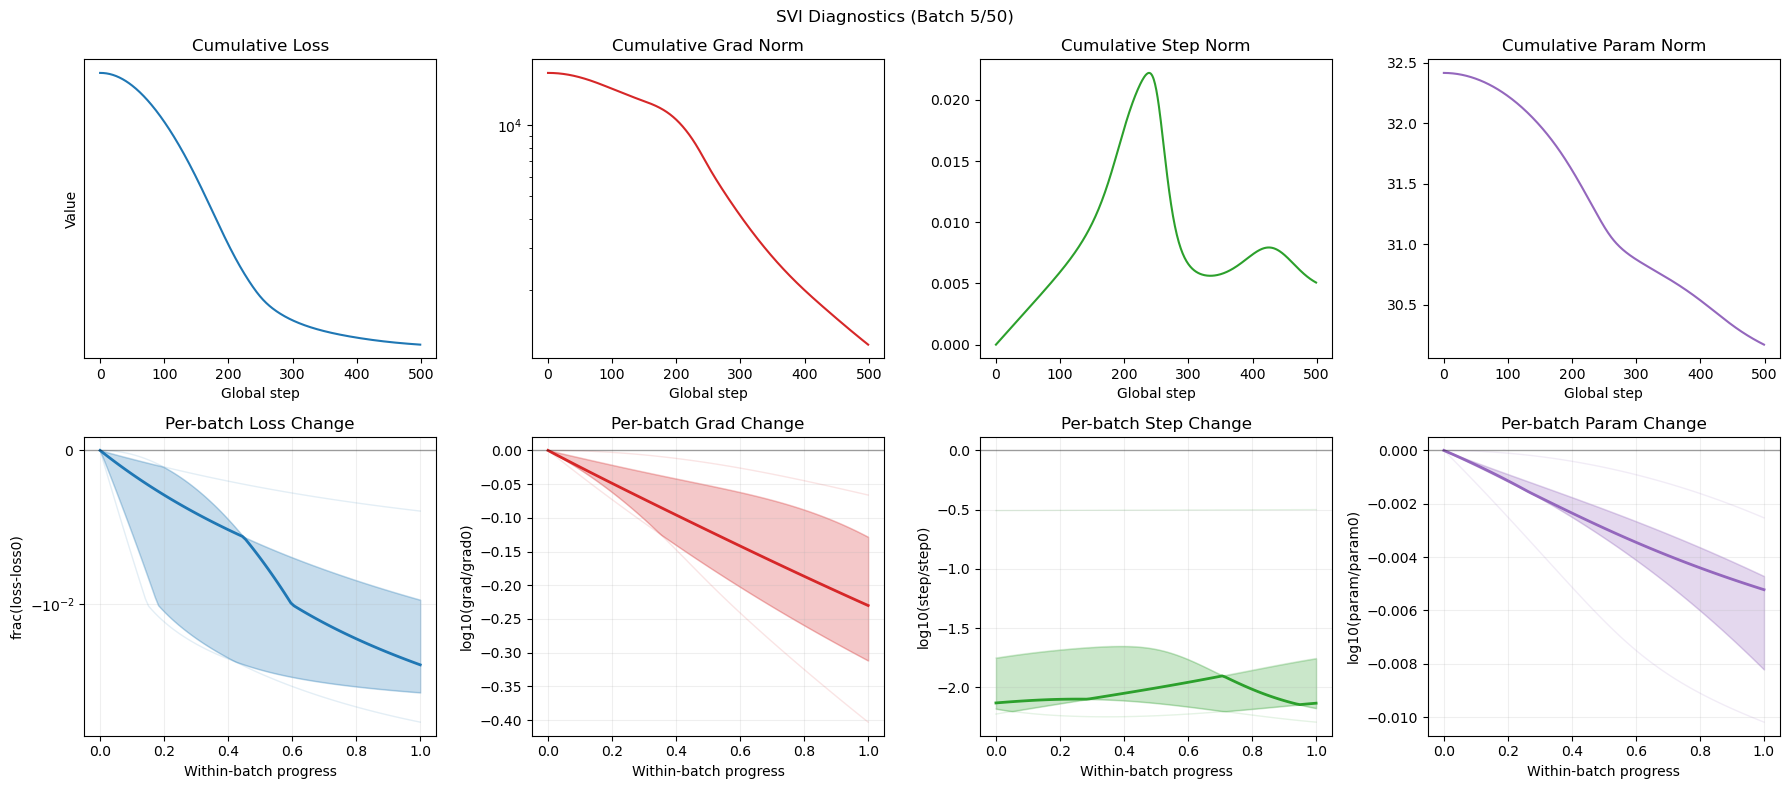

KeyboardInterrupt: 

In [40]:
# This is the noise run
mo_new = copy.deepcopy(mo) # Don't edit OG mo
lu.remove_noise(mo_new)    # Remove any previous noise components

# Set up new noise run/componenets; use same path tree as figs
base_op_dir = f'{out_cfg.root_fig_dir}/noise_{tc.config['noise_run']['inference']['sampler']}/'
samp = nu.model_noise(
    mo_new, to,
    using_wideband = using_wideband,
    run_noise_analysis = True,
    model_kwargs=tc.config['noise_run']['model'],
    sampler_kwargs=tc.config['noise_run']['inference'],
    resume=True,
    return_sampler_without_sampling=False,
    base_op_dir=base_op_dir,
    )

# Add noise and segmentation to PINT model
Requires two pieces of information:
1. Results from a previous noise analysis -- stored in `noise_dict`
2. The interpolation basis -- passed in through `tc.config` (not written to config file though)

In [31]:
noise_dict = nu.get_map_noise_values(
    outdir = tc.get_noise_dir(),
    model = mo_new,
)

In [32]:
# Add noise to model
mo_new = nu.add_noise_to_model(mo_new, noise_dict, tc.config['noise_run']['model'])
lu.add_DM1_DM2_and_unfreeze_DM(mo_new, DM2=True,frozen=False)
lu.add_deteriministic_solar_wind_to_model(mo_new, NE_SW=6.67, frozen=False, SWM=1)

In [33]:
list(mo_new.components.keys())

['AstrometryEcliptic',
 'TroposphereDelay',
 'SolarSystemShapiro',
 'SolarWindDispersion',
 'DispersionDM',
 'BinaryDD',
 'FD',
 'AbsPhase',
 'Spindown',
 'PhaseJump',
 'ScaleToaError',
 'EcorrNoise',
 'PLRedNoise',
 'PLDMNoise',
 'TimeDomainSqExpSWNoise']

# Refit timing model -- with noise hyperparameters fixed

In [34]:
fo_noise = tc.construct_fitter(to,mo_new)
fo_noise.model.free_params = tc.get_free_params(fo_noise)

In [35]:
# FIXME -- needa close the noise run plot
from matplotlib import pyplot as plt
plt.close()

Fitted model using downhill_gls method with 23 free parameters to 8158 TOAs
Prefit residuals Wrms = 32.86864261792684 us, Postfit residuals Wrms = 11.691481043068356 us
Chisq = 8463.325 for 8134 d.o.f. for reduced Chisq of 1.040

PAR                        Prefit                  Postfit            Units
=================== ==================== ============================ =====
PSR                             B1953+29 B1953+29                     None
EPHEM                              DE440 DE440                        None
CLOCK                       TT(BIPM2023) TT(BIPM2023)                 None
UNITS                                TDB TDB                          None
START                            54998.3                      53945.2 d 
FINISH                           60721.8                      60721.8 d 
INFO                                  -f -f                           None
TIMEEPH                             FB90 FB90                         None
T2CMETHOD             

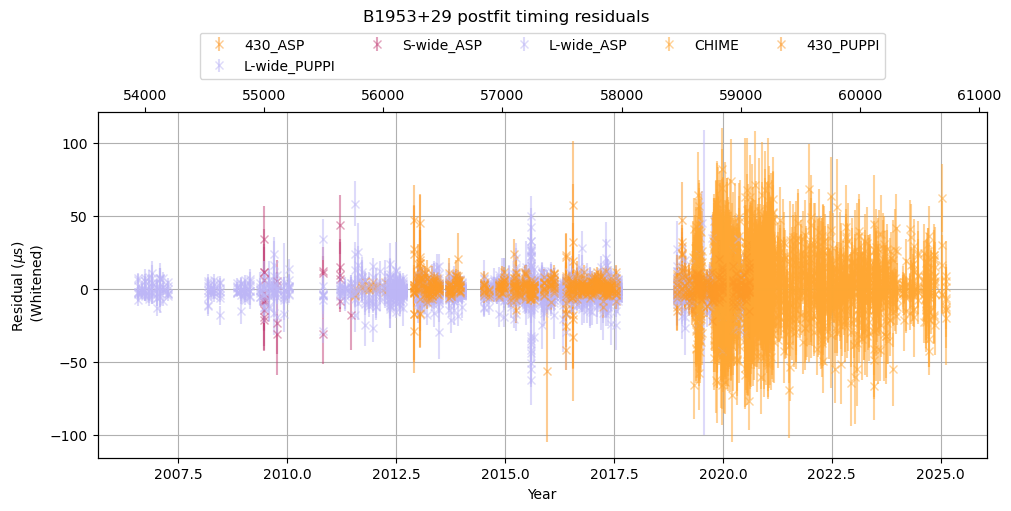

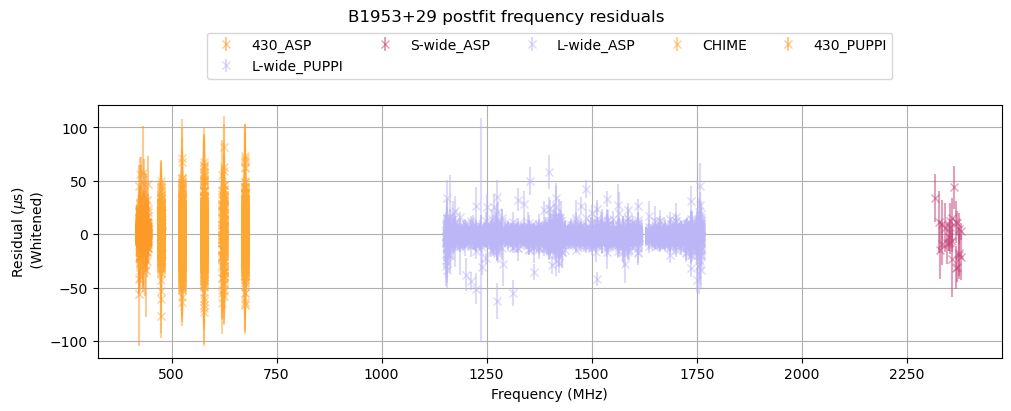

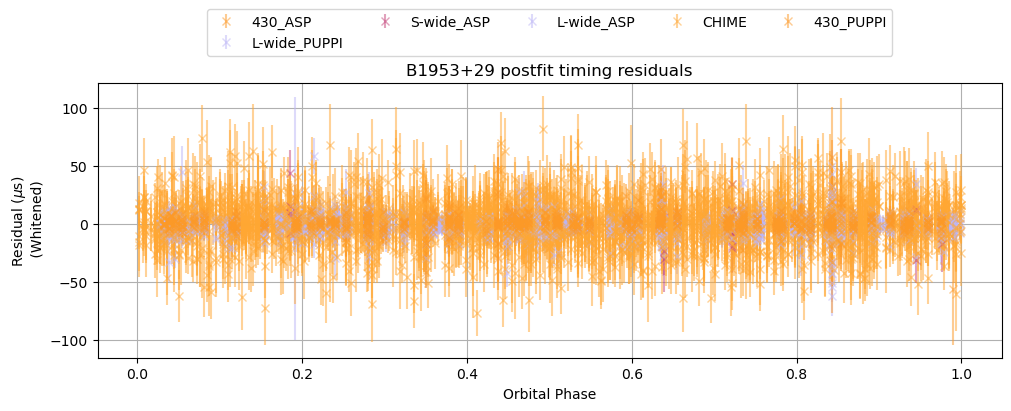

In [36]:
try:
    fo_noise.fit_toas(maxiter=1)
    fo_noise.model.CHI2.value = fo_noise.resids.chi2
except ConvergenceFailure:
    run_Ftest = False
    log.warning('Failed to converge; moving on with best result, but should address before final version.')

pu.plot_residuals_time(fo_noise, restype='postfit', whitened=True)

pu.plot_residuals_freq(fo_noise, restype='postfit', whitened=True)

if mo.is_binary:
    pu.plot_residuals_orb(fo_noise, restype='postfit', whitened=True)
#if not autorun: fo_noise.print_summary()

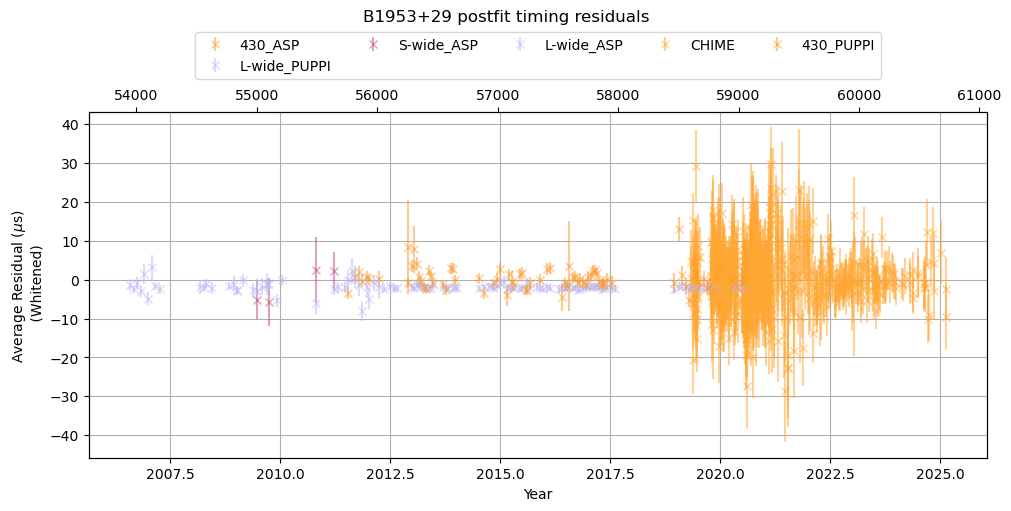

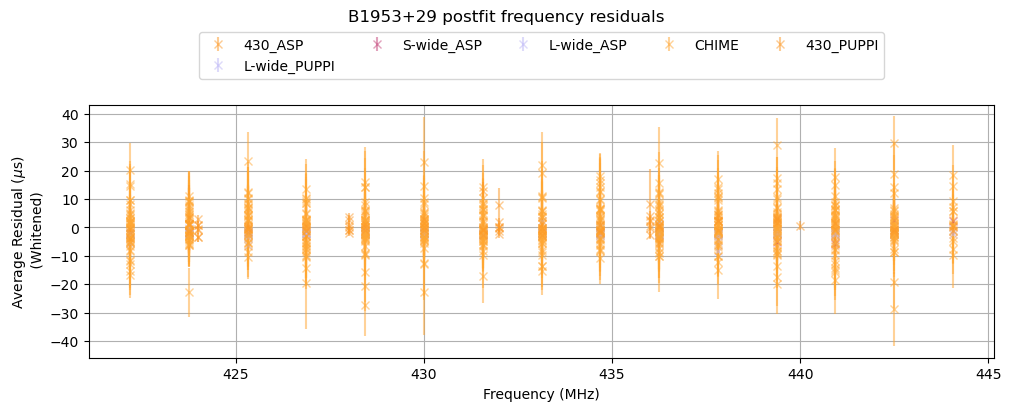

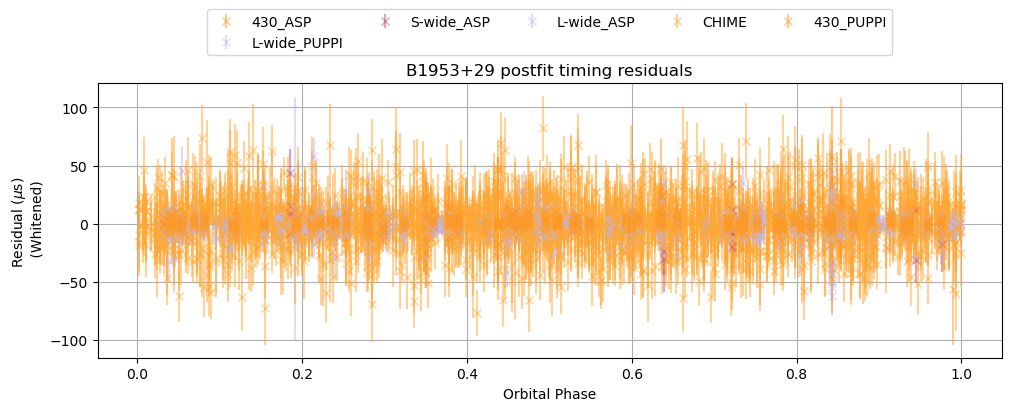

Fitted model using downhill_gls method with 23 free parameters to 8158 TOAs
Prefit residuals Wrms = 32.86864261792684 us, Postfit residuals Wrms = 11.691481043068356 us
Chisq = 8463.325 for 8134 d.o.f. for reduced Chisq of 1.040

PAR                        Prefit                  Postfit            Units
=================== ==================== ============================ =====
PSR                             B1953+29 B1953+29                     None
EPHEM                              DE440 DE440                        None
CLOCK                       TT(BIPM2023) TT(BIPM2023)                 None
UNITS                                TDB TDB                          None
START                            54998.3                      53945.2 d 
FINISH                           60721.8                      60721.8 d 
INFO                                  -f -f                           None
TIMEEPH                             FB90 FB90                         None
T2CMETHOD             

In [37]:
pu.plot_residuals_time(fo_noise, restype='postfit', whitened=True, avg=True)

pu.plot_residuals_freq(fo_noise, restype='postfit', whitened=True, avg=True)

if mo.is_binary:
    pu.plot_residuals_orb(fo_noise, restype='postfit', whitened=True)
    
plt.show()
#if not autorun: fo_noise.print_summary()

In [ ]:
# write par, tim, dmx files
outpar = None  # None leads to default string value
lu.write_par(fo_noise,toatype=tc.get_toa_type(),outfile=outpar,include_date=True)

to.table = to.orig_table # resurrect cut TOAs to write, commented
fo_cuts = tc.construct_fitter(to,mo)
outtim = None  # None leads to default string value
lu.write_tim(fo_cuts,toatype=tc.get_toa_type(),outfile=outtim,commentflag='cut')
apply_cut_select(to,reason='resumption after write_tim') # de-select cut TOAs once again

#dmx_dict = dmxparse(fo_noise, save="dmxparse.out")  # requires DMX bins in model to run properly

# check [excision] results

Check the percentage of good TOAs compared to automatically and manually excised TOAs. An excision "donut" plot will be included in the notebook as well as a warning if lots of TOAs have been excised.

In [ ]:
cuts_dict = None
if check_excision:
    cuts_dict = lu.cut_summary(to, tc, print_summary=True, save=True)
    lu.plot_cuts_all_backends(to, save=True, using_wideband=using_wideband, source_name=tc.get_source())
    lu.highlight_cut_resids(to, mo, tc, ylim_good=True, save=True)

# \[compare\] to previous timing model

Compare post-fit model to `compare-model` (or pre-fit model, if `compare-model` is not specified in the `.yaml` file). Use `?mo.compare` for more information about verbosity options.

In [ ]:
lu.compare_models(fo_noise,
               model_to_compare=tc.get_compare_model(),
               verbosity='check',
               nodmx=True,
               threshold_sigma=3.)

# check parameter \[significance\]

Get information on the weighted (W)RMS residuals per backend. Set `epoch_avg = True` to get the (W)RMS of the epoch-averaged residuals (does not work for wideband analysis; the timing model must have `ECORR` in order for epoch averaging to work). Set `whitened = True` to get the (W)RMS of the whitened residuals. Set both to `True` to get the (W)RMS of the whitened, epoch-averaged residuals.

For wideband analysis, set `dm_stats = True` to also return the (W)RMS of the DM residuals.

In [ ]:
dm_dict = None
epoch_avg = 'ecorr_noise' in fo_noise.model.get_components_by_category()
if not using_wideband:
    rs_dict = resid_stats(fo_noise, 
                          epoch_avg=epoch_avg,
                          whitened=True, 
                          print_pretty=True)
else:
    rs_dict, dm_dict = resid_stats(fo_noise, 
                                   whitened=True, 
                                   dm_stats=True, 
                                   print_pretty=True)

Run F-tests to check significance of existing/new parameters; `alpha` is the p-value threshold for rejecting the null hypothesis that a parameter is not significant. This cell may take 5-10 minutes to run. 

In [ ]:
Ftest_dict = None
if run_Ftest:
    savedLevel = log.getEffectiveLevel()
    try:
        log.setLevel("WARNING")
        Ftest_dict = run_Ftests(fo_noise, 
                                alpha=0.0027, 
                                NITS=tc.get_niter())
    finally:
        log.setLevel(savedLevel)

# generate \[summary\] pdf

Generate summary plots required for pdf summaries. Note: this cell will output white space for the plots, but will save them and incorporate them into the pdf summaries appropriately.

In [ ]:
if not using_wideband:
    pu.plots_for_summary_pdf_nb(fo_noise)
else:
    pu.plots_for_summary_pdf_wb(fo_noise)

In [ ]:
PARFILE = os.path.join(tc.par_directory,tc.config["timing-model"])
pdf_writer(fo, PARFILE, rs_dict, 
           Ftest_dict=Ftest_dict, 
           dm_dict=dm_dict, 
           previous_parfile=tc.get_compare_model(), 
           fitter_noise=fo_noise,
           cuts_dict=cuts_dict,
           no_corner=tc.get_no_corner())

# \[changelog\] entries

New changelog entries in the `.yaml` file should follow a specific format and are only added for specified reasons (excising TOAs, adding/removing params, changing binary models, etc.). For more detailed instructions, run `lu.new_changelog_entry?` in a new cell. This function can be used to format your entry, which should be added to the bottom of the appropriate `.yaml` file. Note: make sure your git `user.email` is properly configured, since this field is used to add your name to the entry.